# Préparation et normalisation des données

Ce notebook nettoie la table RFM par client, standardise les variables Récence-Fréquence-Montant, vérifie la qualité de la mise à l'échelle et exporte les artefacts nécessaires au clustering.

## Import des librairies et configuration des chemins

In [1]:
from pathlib import Path  # Construire des chemins robustes relatifs au projet.
import os  # Créer les dossiers de sortie si besoin.
import pickle  # Sauvegarder le scaler entraîné.
import pandas as pd  # Manipuler les données.
import matplotlib.pyplot as plt  # Générer les graphiques avant/après.
from sklearn.preprocessing import StandardScaler  # Standardiser les variables RFM.

PROJECT_ROOT = Path('.')  # Racine du projet.
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'  # Dossier des données préparées.
PLOTS_DIR = PROJECT_ROOT / 'plots'  # Dossier des graphiques.
MODELS_DIR = PROJECT_ROOT / 'models'  # Dossier des modèles.
RFM_FILE = PROCESSED_DIR / 'rfm_raw_table.csv'  # Table RFM produite par le notebook 01.
os.makedirs(PLOTS_DIR, exist_ok=True)  # S'assurer que le dossier plots existe.
os.makedirs(MODELS_DIR, exist_ok=True)  # S'assurer que le dossier models existe.

## Charger la table RFM et standardiser

In [2]:
rfm = pd.read_csv(RFM_FILE)  # Charger la table RFM par client.
rfm_columns = ['Recency', 'Frequency', 'Monetary']  # Colonnes à standardiser.
X = rfm[rfm_columns]  # Extraire la matrice de features RFM.
scaler = StandardScaler()  # Initialiser le scaler.
X_scaled = scaler.fit_transform(X)  # Ajuster et transformer les features.
X_scaled_df = pd.DataFrame(X_scaled, columns=rfm_columns)  # Reconstruire un DataFrame avec les mêmes colonnes.

## Vérifier la normalisation

In [3]:
print('Moyennes après mise à l\'échelle (proche de 0 attendu) :')  # Titre diagnostic moyennes.
print(X_scaled_df.mean())  # Afficher les moyennes après scaling.
print('\nÉcarts-types après mise à l\'échelle (proche de 1 attendu) :')  # Titre diagnostic écarts-types.
print(X_scaled_df.std(ddof=0))  # Afficher les écarts-types après scaling.

Moyennes après mise à l'échelle (proche de 0 attendu) :
Recency     -3.165642e-17
Frequency    1.539653e-16
Monetary     9.676792e-17
dtype: float64

Écarts-types après mise à l'échelle (proche de 1 attendu) :
Recency      1.0
Frequency    1.0
Monetary     1.0
dtype: float64


## Visualiser les distributions avant / après normalisation

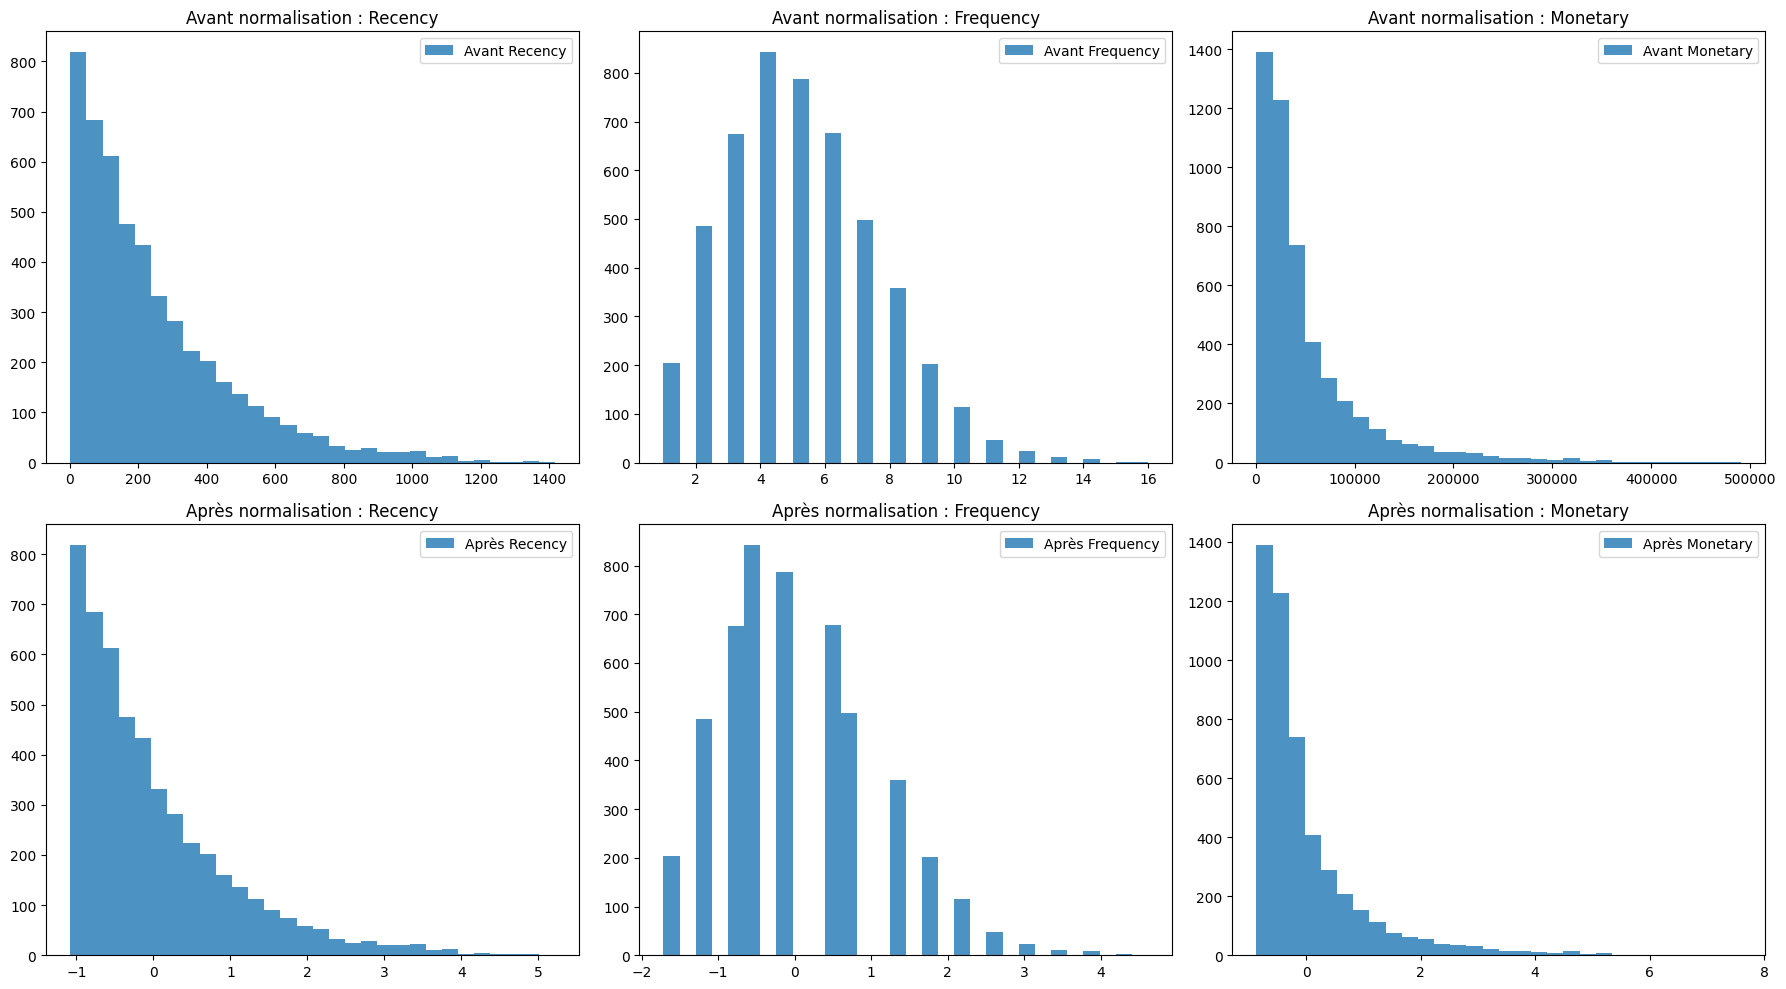

Graphique sauvegardé : plots/distributions.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # Créer une grille 2x3.
for idx, col in enumerate(rfm_columns):  # Parcourir chaque variable RFM.
    axes[0, idx].hist(rfm[col], bins=30, alpha=0.8, label=f'Avant {col}')  # Distribution brute.
    axes[0, idx].set_title(f'Avant normalisation : {col}')  # Titre ligne du haut.
    axes[0, idx].legend()  # Légende.
    axes[1, idx].hist(X_scaled_df[col], bins=30, alpha=0.8, label=f'Après {col}')  # Distribution standardisée.
    axes[1, idx].set_title(f'Après normalisation : {col}')  # Titre ligne du bas.
    axes[1, idx].legend()  # Légende.
plt.tight_layout()  # Éviter le chevauchement.
dist_plot = PLOTS_DIR / 'distributions.png'  # Chemin de sortie du graphique.
plt.savefig(dist_plot, dpi=300)  # Sauvegarder le graphique.
plt.show()  # Afficher le graphique.
print(f'Graphique sauvegardé : {dist_plot}')  # Confirmer le chemin.

## Sauvegarder les données standardisées et le scaler

In [5]:
x_scaled_path = PROCESSED_DIR / 'X_scaled.csv'  # Chemin des features standardisées.
scaler_path = MODELS_DIR / 'scaler.pkl'  # Chemin du scaler entraîné.
X_scaled_df.to_csv(x_scaled_path, index=False)  # Sauvegarder les features standardisées.
with open(scaler_path, 'wb') as f:  # Ouvrir le fichier en écriture binaire.
    pickle.dump(scaler, f)  # Sérialiser le scaler entraîné.
print(f'Sauvegardé : {x_scaled_path}')  # Confirmer la sortie.
print(f'Sauvegardé : {scaler_path}')  # Confirmer la sortie.

Sauvegardé : data/processed/X_scaled.csv
Sauvegardé : models/scaler.pkl
